# Bài tập lớn: Phân tích và dự đoán bệnh tim mạch
**Nhóm 14**

## I. Định nghĩa bài toán

Bệnh tim mạch là nguyên nhân tử vong hàng đầu trên thế giới. Việc
chẩn đoán sớm dựa trên các chỉ số lâm sàng giúp can thiệp kịp thời
và giảm nguy cơ tử vong đáng kể.

Notebook này thực hiện toàn bộ quy trình phân tích và xây dựng mô
hình phân loại bệnh tim (có bệnh / không có bệnh) từ dữ liệu lâm sàng
của 920 bệnh nhân từ 4 bệnh viện: Cleveland, Hungary, Switzerland
và VA Long Beach.

**Dataset:** UCI Heart Disease Repository

**Bài toán:** Dự đoán bệnh nhân có bệnh tim hay không

**Loại:** Binary Classification (Phân loại bệnh hoặc không bệnh)

**Metrics:** Recall (Ưu tiên) — hạn chế bỏ sót bệnh nhân có bệnh, và Precision cũng phải hợp lý để tránh lãng phí tài nguyên bệnh viện khi bắt nhầm người khoẻ mạnh

**MỤC LỤC**
- [I. Định nghĩa bài toán]()
- [II. Exploratory Data Analysis (EDA)]()
- [III. Preprocessor]()
- [IV. Modeling]()
- [V. Evaluation]()
- [VI. Model Persistence]()

**Import các thư viện cần thiết**

In [2]:
# Standard Library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from scipy import stats
from datetime import date
from pathlib import Path

# Sklearn Library
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    StratifiedKFold
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score
)

# Wandb Library
import wandb

# Joblib Library
import joblib as jb

**Một số cấu hình cần thiết**

In [3]:
# Khai báo hằng số
RANDOM_STATE = 42
THRESHOLD = 0.4

In [4]:
# Cố định random state để kết quả mỗi lần chạy là như nhau
np.random.seed(RANDOM_STATE)
os.environ['PYTHONHASHSEED'] = '42'

In [5]:
# Cấu hình của Wandb
WANDB_PROJECT = "heart-disease-classification"
WANDB_ENTITY  = "phat-05"

In [6]:
# Thiết lập style cho biểu đồ
sns.set_theme(style="whitegrid", context="notebook")
sns.set_palette('Set2')

---

## II. Exploratory Data Analysis (EDA)

### 1. Load data

In [7]:
# Định nghĩa đường dẫn tới file dataset
dataset_path = Path().resolve().parent / "data/dataset.csv"

# Load data
df = pd.read_csv(dataset_path)

### 2. Data Overview

Hiển thị tổng quan về các thông tin cơ bản của dataset: số hàng, số cột, kiểu dữ liệu, số giá trị non-null mỗi cột, ...

In [8]:
# Thông tin số dòng số cột
print(f"- Dataset có {df.shape[0]} dòng và {df.shape[1]} cột.")

- Dataset có 920 dòng và 16 cột.


In [9]:
#Thông tin kiểu dữ liệu từng cột, số giá trị non-null
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB


In [10]:
#Thông tin về trung bình, độ lệch chuẩn, tứ phân vị, giá trị nhỏ nhất lớn nhất
print("- Các thông tin thống kê numerical:")
display(df.describe())

print("- Các thông tin thống kê categorical:")
display(df.describe(include=['object', 'string']))

- Các thông tin thống kê numerical:


,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


- Các thông tin thống kê categorical:


,sex,dataset,cp,fbs,restecg,exang,slope,thal
count,920,920,920,830,918,865,611,434
unique,2,4,4,2,3,2,3,3
top,Male,Cleveland,asymptomatic,False,normal,False,flat,normal
freq,726,304,496,692,551,528,345,196


In [11]:
# Xem 5 hàng dữ liệu đầu tiên
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


**Như vậy:** Ta xác định được các cộc numerical và các cột categorical

In [12]:
# Các cột numerical
num_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

# Các cột categorical
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

**Chuẩn hoá biến mục tiêu**

Hiện tại biến mục tiêu trong dataset gốc đang có giá trị từ 0 đến 4, trong đó 0 = không bệnh và 1 đến 4 biểu thị mức độ bệnh.

Tuy nhiên, bài toán đã xác định loại bài toán là **Binary Classification** - phân loại nhị phân (có bệnh/không bệnh).

Vì vậy, nhóm quyết định thêm cột target để làm biến mục tiêu: (0: num = 0; 1: num > 0)

In [13]:
# Dùng hàm astype để convert tất cả dữ liệu trong cột từ bool thành int
df['target'] = (df['num'] > 0).astype(int)

#Hiển thị dữ liệu đã thêm target
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num,target
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2,1
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0,0


### 3. Missing Value Analysis

**Phân tích giá trị thiếu (Missing Value Analysis)** nhằm xác định sự tồn tại và mức độ thiếu hụt dữ liệu trong tập dữ liệu. Các giá trị thiếu có thể phát sinh do lỗi thu thập, nhập liệu hoặc các yếu tố khách quan trong quá trình ghi nhận dữ liệu.

Trong nghiên cứu này, các biến lâm sàng có thể chứa giá trị thiếu, ảnh hưởng đến tính toàn vẹn và độ tin cậy của dữ liệu. Nếu không được xử lý phù hợp, các giá trị thiếu có thể gây sai lệch trong phân tích thống kê và làm giảm hiệu suất của mô hình machine learning.

Do đó, việc thực hiện Missing Value Analysis là cần thiết để xác định và lựa chọn phương pháp xử lý phù hợp (loại bỏ hoặc thay thế), đảm bảo chất lượng dữ liệu trước khi tiến hành các bước phân tích và xây dựng mô hình.

In [14]:
missing_summary = pd.DataFrame({
    'column': df.columns,
    'missing_count': df.isnull().sum(),
    'missing_percent': df.isnull().mean() * 100
}).sort_values(by='missing_percent', ascending=False)

print(missing_summary)

            column  missing_count  missing_percent
ca              ca            611        66.413043
thal          thal            486        52.826087
slope        slope            309        33.586957
fbs            fbs             90         9.782609
oldpeak    oldpeak             62         6.739130
trestbps  trestbps             59         6.413043
exang        exang             55         5.978261
thalch      thalch             55         5.978261
chol          chol             30         3.260870
restecg    restecg              2         0.217391
id              id              0         0.000000
dataset    dataset              0         0.000000
cp              cp              0         0.000000
age            age              0         0.000000
sex            sex              0         0.000000
num            num              0         0.000000
target      target              0         0.000000


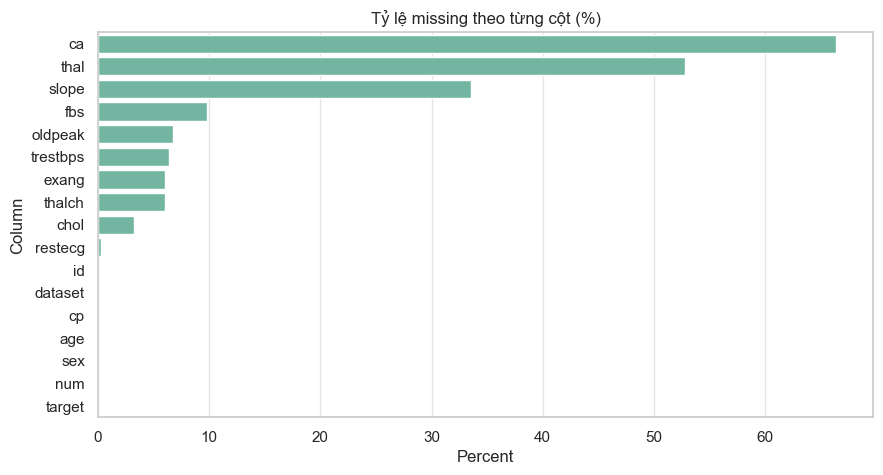

In [15]:
plt.figure(figsize=(10,5))
sns.barplot(x='missing_percent', y='column', data=missing_summary)
plt.title('Tỷ lệ missing theo từng cột (%)')
plt.xlabel('Percent')
plt.ylabel('Column')
plt.show()

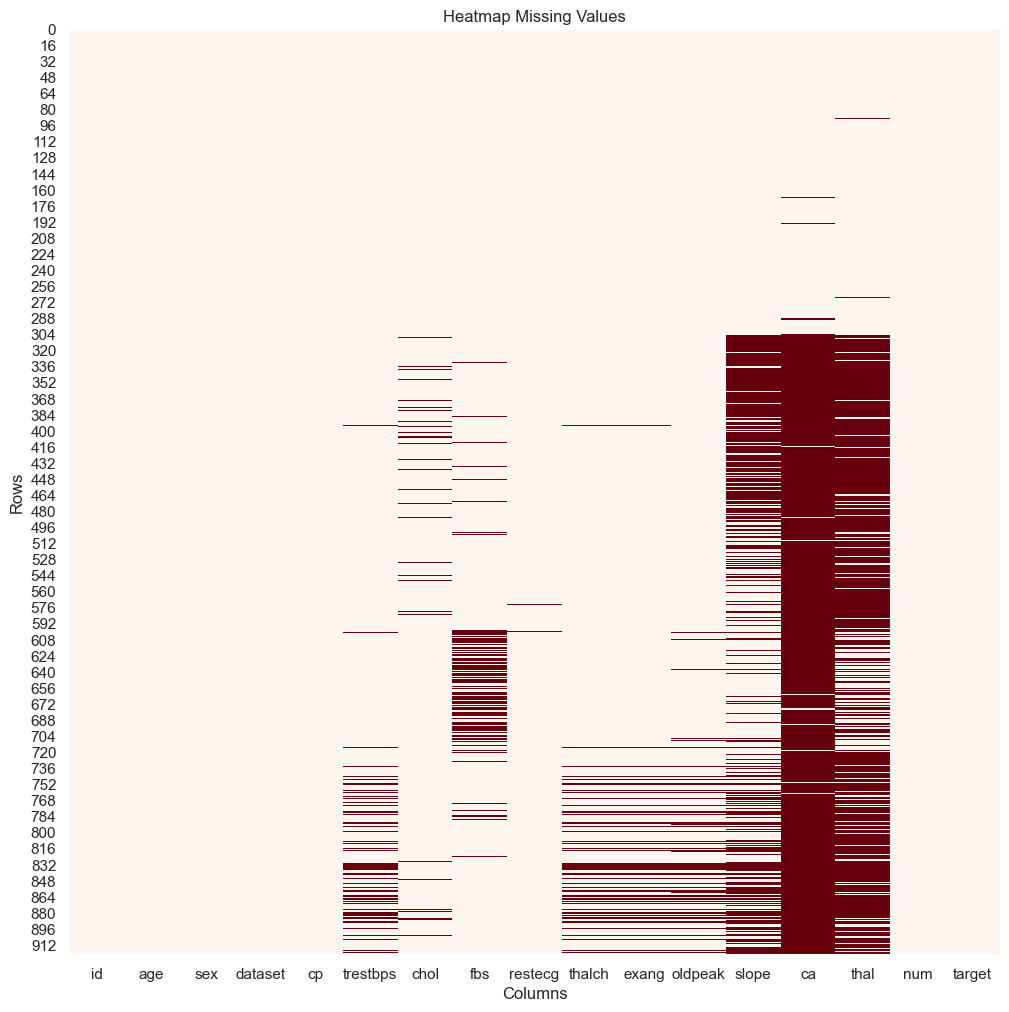

In [16]:
plt.figure(figsize=(12,12))
sns.heatmap(df.isnull(), cbar=False, cmap='Reds')
plt.title('Heatmap Missing Values')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

**Các cột có tỉ lệ missing value > 50%**

In [28]:
# tổng số missing toàn dataset
total_missing = df.isnull().sum().sum()
print("Tổng số giá trị thiếu:", total_missing)

# cột nào > 50% missing
high_missing_cols = missing_summary[missing_summary['missing_percent'] > 50]
print("Cột có >50% missing:\n", high_missing_cols.round(2))

Tổng số giá trị thiếu: 1759
Cột có >50% missing:
      column  missing_count  missing_percent
ca       ca            611            66.41
thal   thal            486            52.83


**Nhận xét :**
- Dataset có tình trạng thiếu dữ liệu khá rõ rệt, đặc biệt ở một số cột quan trọng.
- Hai cột ca và thal có tỷ lệ thiếu vượt quá 50%, điều này ảnh hưởng trực tiếp đến chất lượng mô hình nếu không xử lý.
- Một số cột khác như slope (33.6%), fbs (9.8%), oldpeak (6.7%), trestbps (6.4%) cũng có tỷ lệ thiếu đáng kể, cần cân nhắc phương pháp điền giá trị hoặc loại bỏ.
- Các cột còn lại nhìn chung khá đầy đủ, tỷ lệ thiếu thấp (<10%), có thể xử lý đơn giản.
- Không thấy pattern thiếu dữ liệu theo hàng, nghĩa là dữ liệu bị thiếu mang tính ngẫu nhiên.

### 4. Target Analysis

**Phân tích biến mục tiêu (Target Analysis)** nhằm hiểu rõ phân phối, mức độ cân bằng và chất lượng của biến dự đoán trước khi xây dựng mô hình. Trong nghiên cứu này, nhóm sử dụng biểu đồ CountPlot để phân tích cột `target` từ dataset.

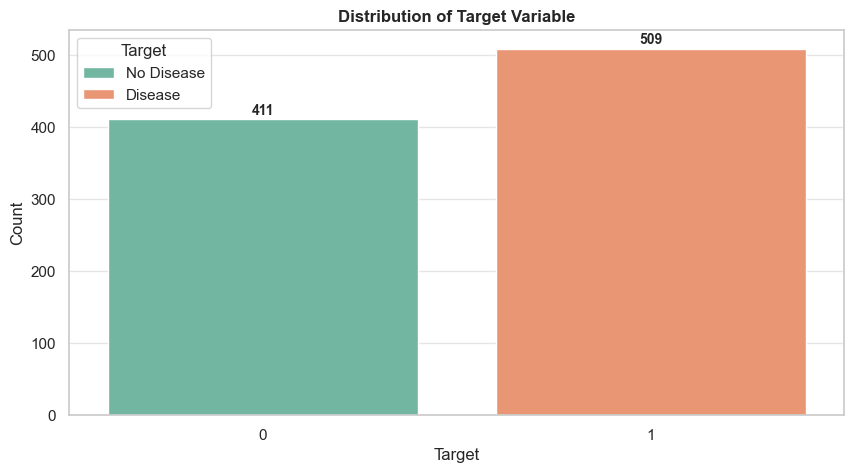

In [18]:
# Vẽ biểu đồ cột cho thấy số lượng giá trị bệnh và không bệnh trong target
plt.figure(figsize=(10, 5))

ax = sns.countplot(data=df, x='target', hue='target')

# Gán nhãn cho các cột
for c in ax.containers:
    ax.bar_label(container=c, fontsize=10, fontweight='bold', padding=1)

# Đổi legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['No Disease', 'Disease'], title="Target")

# Tiêu đề
ax.set_title("Distribution of Target Variable", fontweight='bold')
ax.set_xlabel("Target")
ax.set_ylabel("Count")

plt.show()

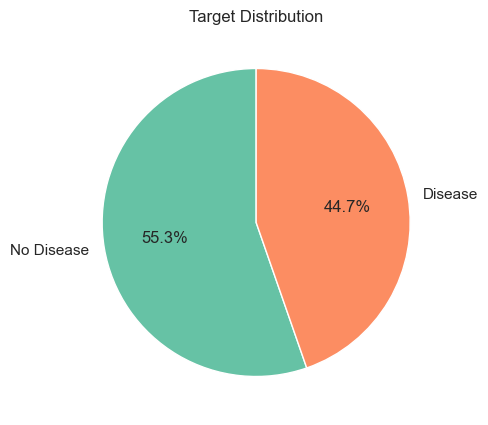

In [19]:
# Tính tỉ lệ phân phối biến mục tiêu
disease_percent = df['target'].value_counts(normalize=True)

# Vẽ biểu đồ tròn thể hiện tỉ lệ phân phối biến mục tiêu
plt.figure(figsize=(5, 5))
plt.pie(disease_percent,
        labels=['No Disease', 'Disease'],
        autopct='%1.1f%%',
        startangle=90)

plt.title("Target Distribution")

plt.show()

 **Nhận xét:**

- **Số lượng:** Tập dữ liệu gồm **411** trường hợp không mắc bệnh và **509** trường hợp mắc bệnh.

- **Tỷ lệ phân phối:** Nhóm không mắc bệnh chiếm khoảng **44.7%**, trong khi nhóm mắc bệnh chiếm khoảng **55.3%**, cho thấy sự chênh lệch không đáng kể giữa hai lớp.

- **Ý nghĩa mô hình:** Với phân phối tương đối cân bằng này, mô hình có thể học ổn định trên cả hai lớp mà không cần áp dụng các kỹ thuật xử lý mất cân bằng phức tạp.

### 5. Categorical Analysis

**Phân tích biến phân loại(Categorical Analysis)** nhằm hiểu rõ phân phối và tần suất xuất hiện của các nhóm dữ liệu định tính trong tập dữ liệu, từ đó hỗ trợ đánh giá đặc điểm dữ liệu và mối quan hệ với biến mục tiêu.

Trong nghiên cứu này, nhóm sử dụng biểu đồ **CountPlot** để trực quan hóa các biến phân loại như giới tính, loại đau ngực, kết quả điện tâm đồ,... Qua đó, có thể quan sát được sự phân bố của từng nhóm và phát hiện các đặc điểm nổi bật hoặc sự chênh lệch giữa các giá trị.

Việc phân tích này giúp cung cấp cái nhìn tổng quan về dữ liệu, đồng thời hỗ trợ quá trình lựa chọn đặc trưng và xây dựng mô hình hiệu quả hơn.

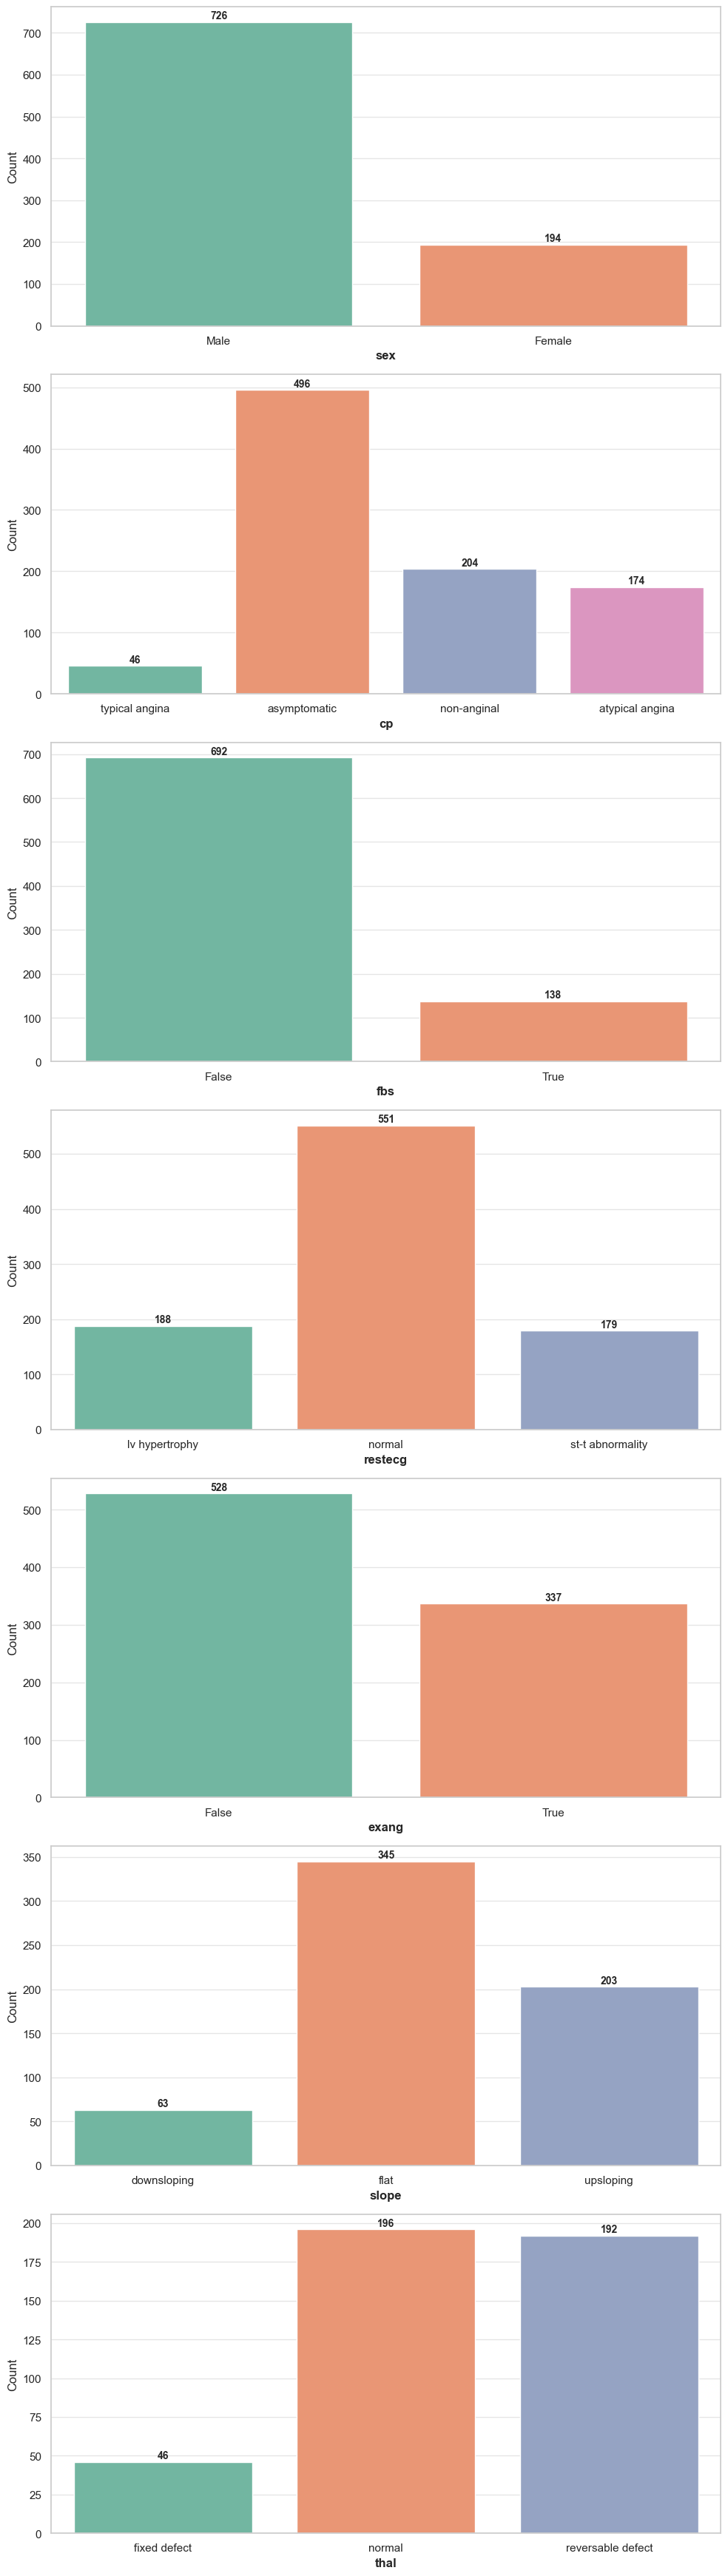

In [20]:
# Vẽ các biểu đồ countplot cho danh sách các biến phân loại
fig, axes = plt.subplots(nrows=len(cat_cols), figsize=(10, 5 * len(cat_cols)))

for i, col in enumerate(cat_cols):
    ax = axes[i]
    sns.countplot(data=df, x=col, hue=col, ax=ax, legend=False)

    for c in ax.containers:
        ax.bar_label(container=c, fontsize=10, fontweight='bold', padding=1)

    ax.set_xlabel(col, fontweight='bold')
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

**Nhận xét:**

**-Tại biểu đồ sex:** Dữ liệu có sự mất cân bằng giới tính. Số lượng Nam giới tham gia khảo sát đông hơn rất nhiều so với Nữ giới (726 Nam so với 194 Nữ).

**-Tại biểu đồ cp:** Đau ngực loại asymptomatic (không triệu chứng) chiếm tỷ lệ cao nhất (496 ca). Các loại đau thắt ngực điển hình (typical angina) chiếm tỷ lệ thấp nhất (46 ca).

**-Tại biểu đồ fbs:** Đa số người tham gia có đường huyết lúc đói dưới 120 mg/dl (692 ca). Chỉ có một nhóm nhỏ (138 ca) có chỉ số đường huyết cao (> 120 mg/dl).

**-Tại biểu đồ exang:** Số lượng người không bị đau ngực khi vận động (False - 528 ca) cao hơn đáng kể so với nhóm có bị đau ngực khi vận động (True - 337 ca).

**-Tại biểu đồ restecg:** Kết quả điện tâm đồ lúc nghỉ ngơi phần lớn là normal (551 ca). Các tình trạng bất thường như lv hypertrophy hay st-t abnormality chiếm số lượng ít hơn và khá tương đồng nhau.

**-Tại biểu đồ slope:** Độ dốc của đoạn ST sau tập luyện chủ yếu là flat (345 ca) và upsloping (203 ca). Loại downsloping chiếm tỷ lệ rất thấp (63 ca).

**-Tại biểu đồ thal:** Tình trạng thiếu máu cục bộ cơ tim phổ biến nhất là normal (196 ca) và reversable (192 ca). Loại fixed defect chỉ chiếm một phần nhỏ (46 ca).

**Kết luận:** Tập dữ liệu cho thấy đối tượng khảo sát điển hình là Nam giới, có kết quả điện tâm đồ bình thường, nhưng phần lớn lại gặp tình trạng đau ngực không triệu chứng (asymptomatic). Đây là một điểm đáng lưu ý vì bệnh có thể tiến triển âm thầm mà không có biểu hiện đau thắt ngực điển hình.

### 6. Distribution Analysis

**Phân tích phân phối (Distribution Analysis)** là quan sát các giá trị trong một cột dữ liệu được phân bố như thế nào và dữ liệu được tập trung ở đâu hay dữ liệu có bị lệch hay không?
Phân tích phân phối giúp ta xác định:
* Dữ liệu có bị lệch hay không?
* Feature nào quan trọng với mô hình?
* Feature nào không quan trọng?

Ở đây, nhóm chọn biểu đồ **KDE ()** vì biểu đồ này thể hiện sự chồng lên nhau của 2 nhóm có bệnh và không bệnh rõ ràng nhất.

Trong phần này, nhóm sẽ tập chung phân tích các cột dữ liệu là: age, trestbps, chol, thalch, oldpeak, ca vì các cột này có dữ liệu là numerical liên tục trong 1 khoảng.

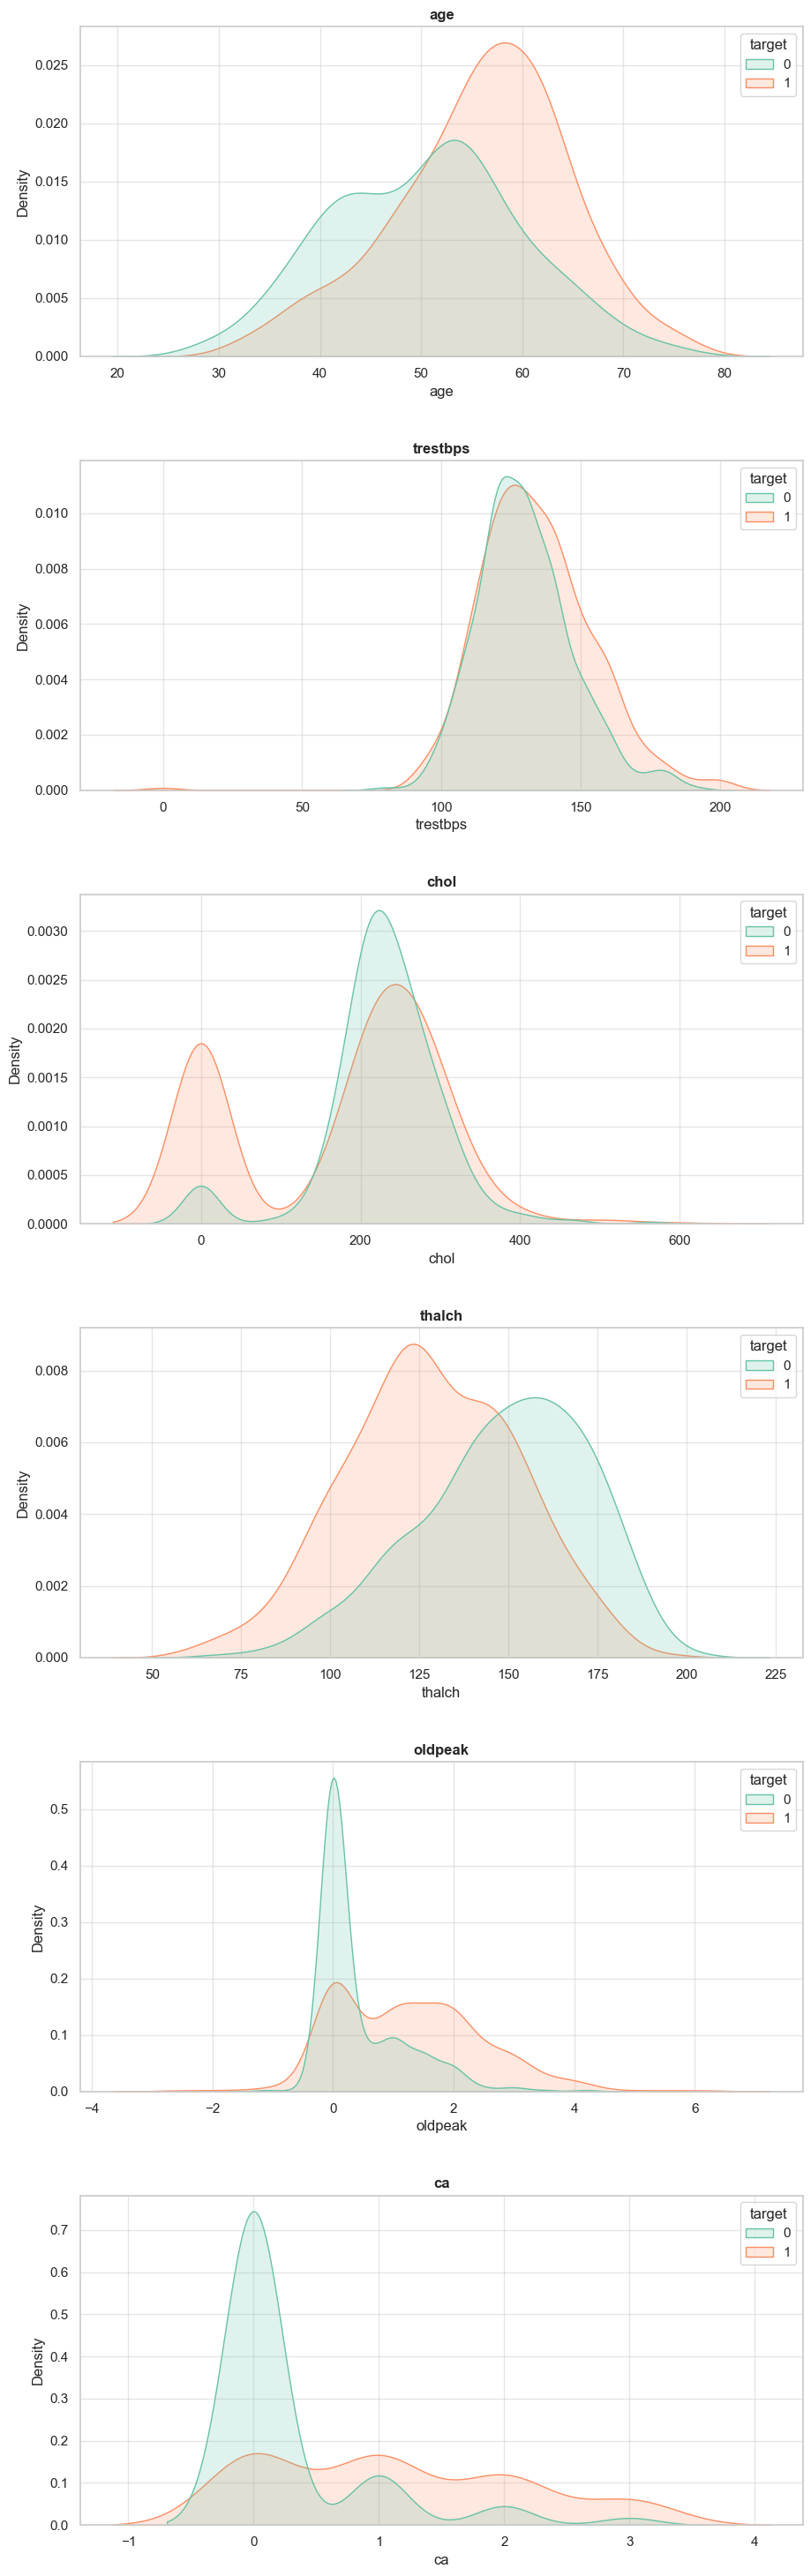

In [21]:
# Vẽ biểu đồ KDE
fig, axes = plt.subplots(nrows=len(num_cols), ncols=1, figsize=(10, 5 * len(num_cols)))

for i, col in enumerate(num_cols):
        sns.kdeplot(
            data=df,
            x=col,
            hue='target',
            ax=axes[i],
            fill=True,
            alpha=0.2
        )
        axes[i].set_title(col, fontweight='bold')
        axes[i].set_xlabel(col)
plt.tight_layout(pad=3.0)
plt.show()

**Nhận xét:**
* **age**:
    * Nhóm không bệnh phân bố tập trung ở độ tuổi 40 - 55
    * Nhóm có bệnh phân bố tập trung ở độ tuổi 55 - 60

    Hai nhóm có chồng lên nhau nhưng dữ liệu có phần lệch hơn về phía bên phải

    -> Feature này có giá trị trung bình
* **trestbps**:

    Hai nhóm phân phối lệch phải và gần như chồng lên nhau

    -> Feature này có giá trị yếu
* **chol**:

    Hai nhóm phân phối lệch trái và gần như chồng lên nhau

    -> Feature này có giá trị yếu
* **thalch**:

    Nhóm không bệnh phân bố tập trung ở mức nhịp tim cao, từ 150 - 165

    Nhóm có bệnh phân bố tập trung ở mức nhịp tim thấp hơn, từ 120 - 135

    Hai nhóm tách biệt nhau khá rõ ràng và ít bị chồng chéo, điểm giao cắt rõ nét ở khoảng 145 - 150.

    -> Feature này có giá trị phân loại cao (mạnh nhất).
* **oldpeak**:

    Nhóm không bệnh phân bố tập trung rất cao tại mốc 0.

    Nhóm có bệnh phân bố trải dài hơn, tạo thành các khoảng tập trung ở gần mốc 0 và từ 1.0 đến 2.5.

    Hai nhóm có chồng lên nhau ở mốc 0 nhưng hình dáng khác biệt rõ rệt. Dữ liệu của nhóm có bệnh có phần đuôi dài, lệch hẳn về phía bên phải (lên tới mức 4.0 trở lên).

    -> Feature này có giá trị cao.
* **ca**:

    Nhóm không bệnh phân bố tập trung rất cao tại giá trị **0**, cho thấy đa số bệnh nhân không mắc bệnh không có mạch vành bị nhuộm màu.

    Ngược lại, nhóm có bệnh phân bố trải rộng hơn từ **0 đến 3**, với mật độ giảm dần khi giá trị tăng. Đặc biệt, nhóm này có tần suất xuất hiện đáng kể ở các giá trị **1, 2 và 3**, trong khi nhóm không bệnh gần như không xuất hiện ở các mức này.

    Hai nhóm có sự chồng lấn tại giá trị 0, tuy nhiên từ giá trị **>= 1** trở đi, sự tách biệt trở nên rõ ràng hơn.

    -> Feature này có giá trị phân loại cao.

**=> Tóm lại**, các đặc trưng **thalch, oldpeak và ca** mang lại giá trị phân loại cao.


### 7. Outlier Analysis

**Phân tích giá trị ngoại lệ (Outlier Analysis)** nhằm phát hiện các giá trị bất thường (outliers) trong tập dữ liệu. Các giá trị này có thể là dữ liệu thực (ví dụ: bệnh nhân có chỉ số rất cao) hoặc do lỗi nhập liệu / dữ liệu thiếu.

Trong nghiên cứu này, các biến y tế như **age, trestbps, chol, thalch, oldpeak** có khả năng xuất hiện các giá trị cực đoan. Nếu không được phát hiện và xử lý kịp thời, các giá trị này có thể làm sai lệch kết quả phân tích thống kê và ảnh hưởng tiêu cực đến hiệu suất của mô hình machine learning.

Do đó, việc thực hiện Outlier Analysis là cần thiết để đảm bảo chất lượng dữ liệu trước khi tiến hành các bước phân tích và xây dựng mô hình tiếp theo.

In [22]:
# Hàm vẽ Boxplot :  Boxplot giúp trực quan hóa phân bố dữ liệu và dễ dàng nhận ra các điểm nằm ngoài phạm vi bình thường.
def plot_boxplot(df, column):

    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[column])

    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)

    plt.show()

In [23]:
# Phát hiện Outlier bằng phương pháp IQR : Phương pháp **Interquartile Range (IQR)** được sử dụng để xác định các giá trị bất thường.
def detect_outlier(df, column):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower) | (df[column] > upper)]

    print(f"\n===== Outlier in {column} =====")
    print("Lower bound:", lower)
    print("Upper bound:", upper)
    print("Number of outliers:", len(outliers))

    return outliers

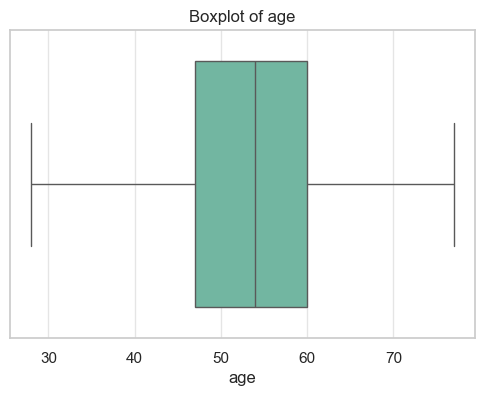


===== Outlier in age =====
Lower bound: 27.5
Upper bound: 79.5
Number of outliers: 0


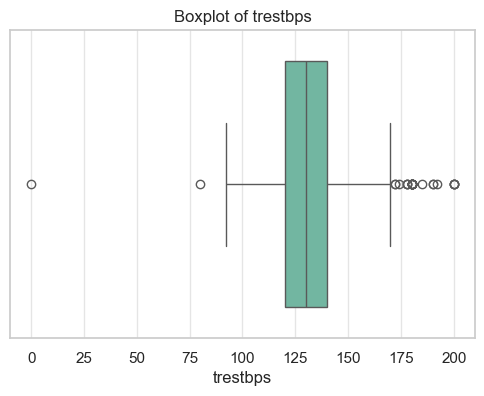


===== Outlier in trestbps =====
Lower bound: 90.0
Upper bound: 170.0
Number of outliers: 28


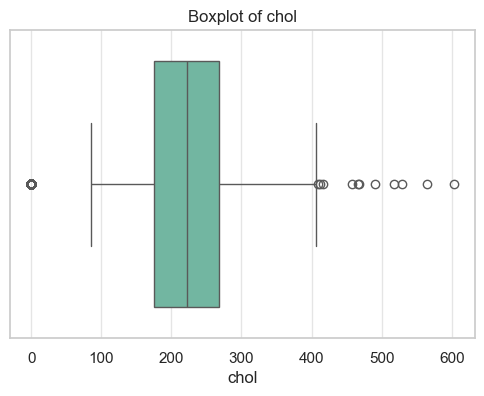


===== Outlier in chol =====
Lower bound: 35.5
Upper bound: 407.5
Number of outliers: 183


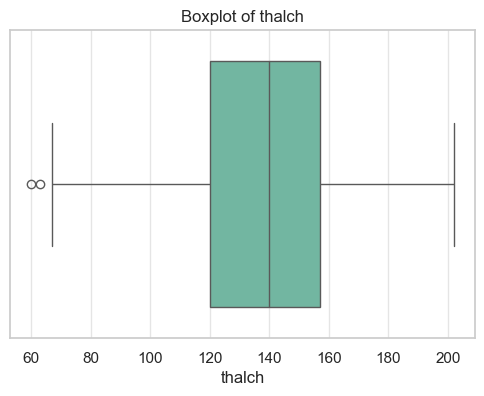


===== Outlier in thalch =====
Lower bound: 64.5
Upper bound: 212.5
Number of outliers: 2


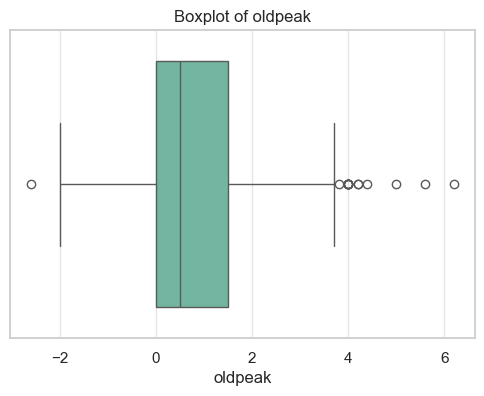


===== Outlier in oldpeak =====
Lower bound: -2.25
Upper bound: 3.75
Number of outliers: 16


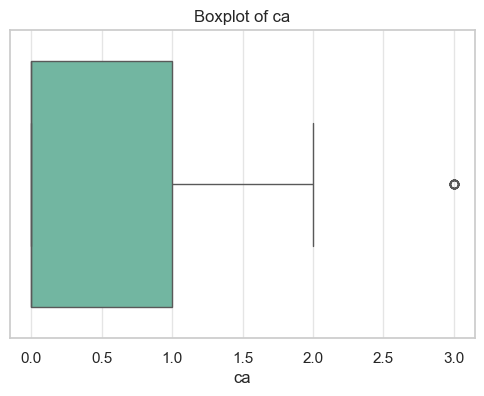


===== Outlier in ca =====
Lower bound: -1.5
Upper bound: 2.5
Number of outliers: 20


In [24]:
# Phân tích Outlier cho từng biến:  Vẽ boxplot và Tính số lượng outlier bằng IQR
for col in num_cols:
    plot_boxplot(df, col)
    detect_outlier(df, col)

In [25]:
# Kiểm tra giá trị cực trị (Min và Max): Sau khi phát hiện outlier, chúng ta cần kiểm tra **giá trị nhỏ nhất và lớn nhất** để xác định: Outlier là dữ liệu thật hay lỗi nhập liệu
for col in num_cols:
    print(f"\nColumn: {col}")
    print("Min:", df[col].min())
    print("Max:", df[col].max())


Column: age
Min: 28
Max: 77

Column: trestbps
Min: 0.0
Max: 200.0

Column: chol
Min: 0.0
Max: 603.0

Column: thalch
Min: 60.0
Max: 202.0

Column: oldpeak
Min: -2.6
Max: 6.2

Column: ca
Min: 0.0
Max: 3.0


### 8. Correlation Analysis

**Phân tích tương quan (Correlation Analysis)** là phương pháp thống kê đánh giá mức độ liên quan giữa 2 hoặc nhiều biến số.

Phân tích tương quan giúp ta xác định:

- Feature nào liên quan mạnh nhất đến bệnh tim?
- Có 2 feature nào mang thông tin trùng lặp nhau không?
- Feature nào nên ưu tiên khi xây dựng mô hình?

Ở đây, nhóm chọn biểu đồ **Heatmap** vì biểu đồ này thể hiện
toàn bộ mối quan hệ giữa tất cả các feature cùng lúc thông qua
màu sắc — màu càng đậm thì tương quan càng mạnh.

Hệ số tương quan có giá trị từ -1 đến 1, trong đó 1 là
tương quan thuận hoàn toàn, 0 là không có tương quan, và -1
là tương quan nghịch hoàn toàn.

Trong phần này, nhóm sẽ encode các cột categorical sang dạng số
trước khi tính tương quan vì hệ số Pearson chỉ tính được trên dữ
liệu số. Việc encode chỉ dùng trong section này, không thay đổi
dữ liệu gốc.

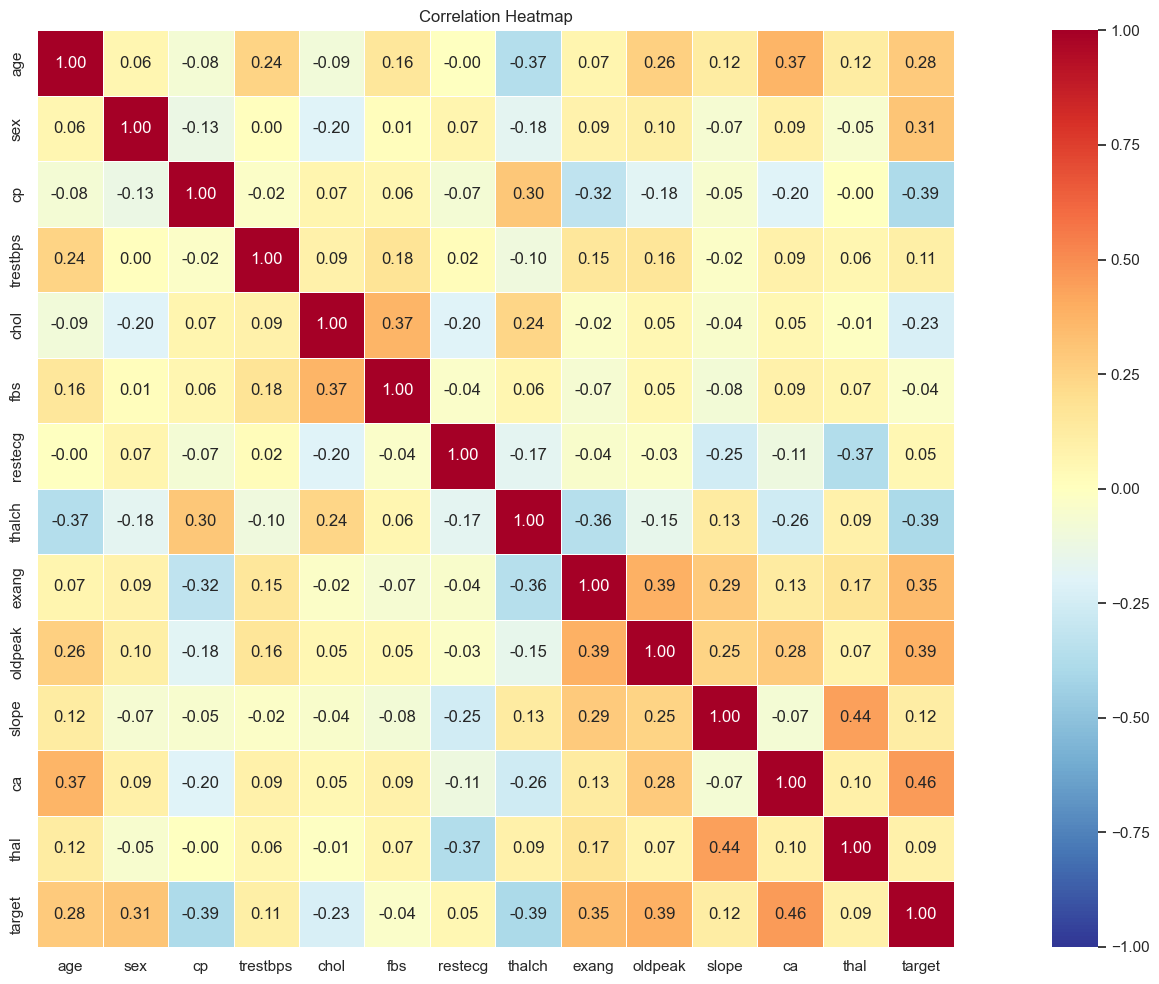

tương quan các cột với target theo độ mạnh:
ca          0.46
thalch     -0.39
oldpeak     0.39
cp         -0.39
exang       0.35
sex         0.31
age         0.28
chol       -0.23
slope       0.12
trestbps    0.11
thal        0.09
restecg     0.05
fbs        -0.04
Name: target, dtype: float64


In [26]:
# Encode các categorical feature
df_encoded = df.copy()

for col in cat_cols:
    df_encoded[col] = pd.Categorical(df_encoded[col]).codes

#trong biểu đồ heatmap này các cột id, dataset không có ý nghĩa so sánh và cột num đã được chuyển thành target, nên không cần dùng các cột này
df_encoded = df_encoded.drop(columns=['id', 'dataset', 'num'])

# Tính ma trận tương quan
corr_matrix = df_encoded.corr()

plt.figure(figsize=(20, 10))
sns .heatmap(
    data=corr_matrix,
    annot=True,
    fmt='.2f',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True,
    cmap='RdYlBu_r'
)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

print('tương quan các cột với target theo độ mạnh:')
print(corr_matrix['target'].drop('target').sort_values(key=abs,ascending=False).round(2))

**Nhận xét:**
* Các feature tương quan mạnh với target (|r| > 0.3):

| Feature | Hệ số | Ý nghĩa |
|---|---|---|
| ca | +0.46 | Số mạch vành bị tắc càng nhiều -> nguy cơ bệnh càng cao |
| thalch | -0.39 | Nhịp tim tối đa càng thấp -> nguy cơ bệnh càng cao |
| oldpeak | +0.39 | ST depression càng cao -> nguy cơ bệnh càng cao |
| cp | -0.39 | Loại đau ngực có liên quan rõ đến bệnh tim |
| exang | +0.35 | Đau ngực khi gắng sức -> dấu hiệu rõ của bệnh tim |
| sex | +0.31 | Giới tính có ảnh hưởng đến nguy cơ bệnh tim |

* Những feature còn lại có tương quan yếu hoặc gần như không tương quan với target

* Những feature có tương quan mạnh với nhau:

| Cặp Feature | Hệ số | Ý nghĩa |
|---|---|---|
| slope vs thal | +0.44 | Khá trùng lặp |
| exang vs oldpeak | +0.39 | Có liên quan nhau |
| chol vs fbs | +0.37 | Cholesterol cao đi đôi với đường huyết cao |
| ca vs age | +0.37 | Người lớn tuổi -> mạch vành dễ bị tắc hơn |
| thalch vs age | -0.37 | Người lớn tuổi -> nhịp tim tối đa thấp hơn |
| thal vs restecg | -0.37 | Kết quả thalassemia liên quan đến ECG |
| thalch vs exang | -0.36 | Nhịp tim tối đa thấp đi đôi với đau ngực khi gắng sức |
| exang vs cp | -0.32 | Loại đau ngực liên quan đến đau khi gắng sức |

**=> Tóm lại,**

- Các feature tương quan mạnh với target có: ca, thalch, oldpeak, cp, exang và sex
-> ưu tiên giữ lại các feature này.

- Các feature tương quan yếu có: thal, restecg và fbs

- Các cặp feature có tương quan mạnh có: slope và thal, exang và oldpeak

### 9. Preprocessing Strategy

Dựa trên quá trình khám phá dữ liệu và tổng hợp kết quả dựa vào các biểu đồ có ý nghĩa, nhóm đã rút ra được các nội dung:

**1. Data Insights**
- **Missing Value:** sau khi phân tích kết quả cho thấy có 2 cột `ca` và `thal` có tỉ lệ khuyết lớn hơn 50%. Tuy nhiên, đây là những chỉ số quan trọng có tương quan với biến mục tiêu nên nhóm quyết định giữ lại và xử dụng kỹ thuật điền khuyết (imputation) cho từng biến:
    - `ca` (numerical): sử dụng **Median** do phân phối lệch
    - `thal` (categorical): sử dụng **Mode** để bảo toàn tính phân loại
    - các cột numerical còn lại: sử dụng **Median** do có thể chứa giá trị outlier và Median giúp tránh bị kéo lệch
    - các cột categorical còn lại: sử dụng **Mode** do các giá trị không phải là số nên không bị kéo lệch
- **Target Variable:** dữ liệu và biểu đồ cho thấy hai lớp (Có bệnh/Không bệnh) không có sự chênh lệch đáng kể, do đó không cần dùng kỹ thuật xử lý. Tuy nhiên, nhóm vẫn dùng chiến lược strategy = y để giữ tỉ lệ lớp được đồng đều
-
-

## III. PREPROCESSING

### 1.